Import Library

In [12]:
import os
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

Konfigurasi folder dan parameter

In [13]:
#  Lokasi model terbaik 
model_path = r"C:\Users\Lenovo\Klasifikasi_ikan\notebook\bagian_training\models\final\final_model_mobilenetv2.keras"
model = tf.keras.models.load_model(model_path)
print("✅ Model berhasil dimuat dari:", model_path)

# Muat ulang dataset (gunakan data validasi atau seluruh dataset normalized_output) 
data_dir = r"C:\Users\Lenovo\Klasifikasi_ikan\datasets\normalized_output"
classes = ["segar", "tidak_segar"]
img_height, img_width = 224, 224

data = []
labels = []

✅ Model berhasil dimuat dari: C:\Users\Lenovo\Klasifikasi_ikan\notebook\bagian_training\models\final\final_model_mobilenetv2.keras


Proses

In [14]:
print("📥 Memuat dataset evaluasi...")
for label in classes:
    path = os.path.join(data_dir, label)
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, (img_width, img_height))
            data.append(img)
            labels.append(label)

data = np.array(data, dtype="float32") / 255.0
labels = np.array(labels)

# Mengubahbah label menjadi numerik 
label_to_index = {label: idx for idx, label in enumerate(classes)}
y_true = np.array([label_to_index[label] for label in labels])

# =Prediksi menggunakan model terbaik
print("🔍 Melakukan prediksi pada dataset evaluasi...")
y_pred_probs = model.predict(data)
y_pred = np.argmax(y_pred_probs, axis=1)

📥 Memuat dataset evaluasi...
🔍 Melakukan prediksi pada dataset evaluasi...
32/32 [==============================] - 5s 141ms/step


Hasil

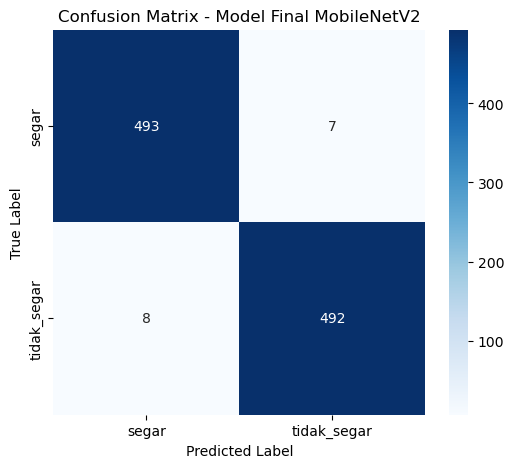


📊 Classification Report:
              precision    recall  f1-score   support

       segar     0.9840    0.9860    0.9850       500
 tidak_segar     0.9860    0.9840    0.9850       500

    accuracy                         0.9850      1000
   macro avg     0.9850    0.9850    0.9850      1000
weighted avg     0.9850    0.9850    0.9850      1000




✅ Evaluasi Akhir Model:
   Akurasi  : 98.50%
   Loss     : 0.0765


In [15]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - Model Final MobileNetV2')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report 
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

# Evaluasi tambahan (opsional)
loss, acc = model.evaluate(data, tf.keras.utils.to_categorical(y_true), verbose=0)
print(f"\n✅ Evaluasi Akhir Model:")
print(f"   Akurasi  : {acc*100:.2f}%")
print(f"   Loss     : {loss:.4f}")

Percobaan Ulang

📊 Ringkasan Hasil Final Training:
Fold 1: Akurasi = 94.00%, Loss = 0.2068
Fold 2: Akurasi = 90.00%, Loss = 0.2547
Fold 3: Akurasi = 95.00%, Loss = 0.1531
Fold 4: Akurasi = 93.00%, Loss = 0.2112
Fold 5: Akurasi = 91.50%, Loss = 0.3095

🔹 Rata-rata Akurasi: 92.70% ± 1.78
🔹 Rata-rata Loss: 0.2271 ± 0.0523


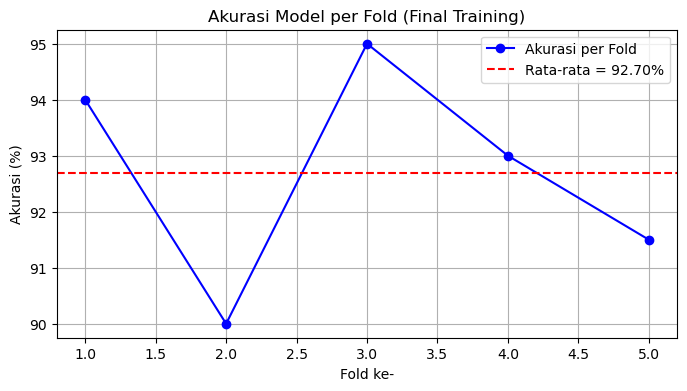

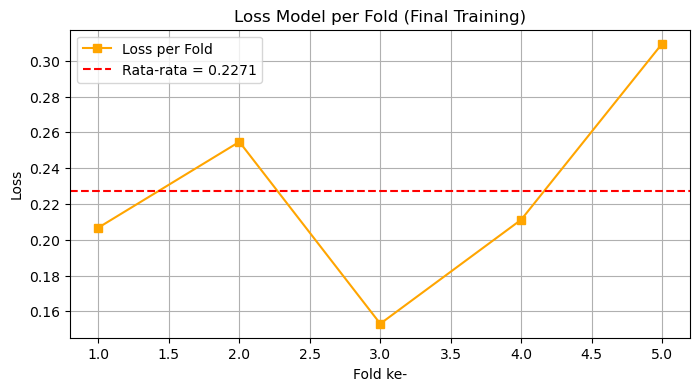

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# === 1. Data hasil final training (dari log ) ===
acc_per_fold = [94.00, 90.00, 95.00, 93.00, 91.50]
loss_per_fold = [0.2068, 0.2547, 0.1531, 0.2112, 0.3095]

# === 2. Hitung statistik ===
mean_acc = np.mean(acc_per_fold)
mean_loss = np.mean(loss_per_fold)
std_acc = np.std(acc_per_fold)
std_loss = np.std(loss_per_fold)

# === 3. Simpan hasil agar bisa dipakai ulang nanti ===
np.savez(r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\final_model\fold_metrics_summary.npz",
         acc_per_fold=acc_per_fold,
         loss_per_fold=loss_per_fold,
         mean_acc=mean_acc,
         mean_loss=mean_loss,
         std_acc=std_acc,
         std_loss=std_loss)

print("📊 Ringkasan Hasil Final Training:")
print("===================================")
for i in range(len(acc_per_fold)):
    print(f"Fold {i+1}: Akurasi = {acc_per_fold[i]:.2f}%, Loss = {loss_per_fold[i]:.4f}")

print(f"\n🔹 Rata-rata Akurasi: {mean_acc:.2f}% ± {std_acc:.2f}")
print(f"🔹 Rata-rata Loss: {mean_loss:.4f} ± {std_loss:.4f}")

# === 4. Visualisasi Akurasi ===
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(acc_per_fold)+1), acc_per_fold, marker='o', color='blue', label='Akurasi per Fold')
plt.axhline(y=mean_acc, color='red', linestyle='--', label=f'Rata-rata = {mean_acc:.2f}%')
plt.title('Akurasi Model per Fold (Final Training)')
plt.xlabel('Fold ke-')
plt.ylabel('Akurasi (%)')
plt.legend()
plt.grid(True)
plt.show()

# === 5. Visualisasi Loss ===
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_per_fold)+1), loss_per_fold, marker='s', color='orange', label='Loss per Fold')
plt.axhline(y=mean_loss, color='red', linestyle='--', label=f'Rata-rata = {mean_loss:.4f}')
plt.title('Loss Model per Fold (Final Training)')
plt.xlabel('Fold ke-')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


semua fold

=== 📊 Hasil Evaluasi Final Model ===
Akurasi Keseluruhan: 92.70%

=== Classification Report ===
              precision    recall  f1-score   support

       Segar     0.9331    0.9200    0.9265       500
 Tidak Segar     0.9211    0.9340    0.9275       500

    accuracy                         0.9270      1000
   macro avg     0.9271    0.9270    0.9270      1000
weighted avg     0.9271    0.9270    0.9270      1000



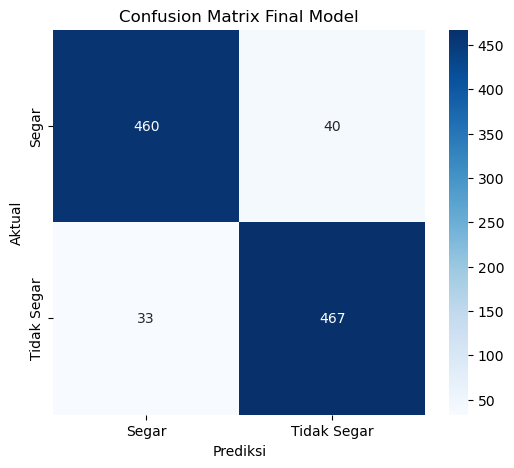

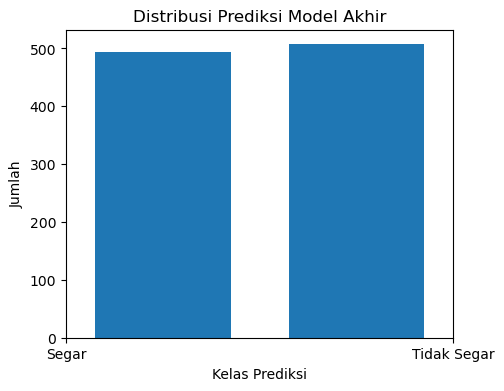

In [7]:
# === 1. Import Library ===
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# === 2. Load hasil evaluasi final ===
data_path = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\final_training\final_evaluation_data.npz"
data = np.load(data_path)

y_true = data['y_true']
y_pred = data['y_pred']

# === 3. Konversi one-hot encoding menjadi label ===
y_true_labels = np.argmax(y_true, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

# === 4. Hitung metrik evaluasi ===
acc = accuracy_score(y_true_labels, y_pred_labels)
cm = confusion_matrix(y_true_labels, y_pred_labels)
report = classification_report(
    y_true_labels,
    y_pred_labels,
    target_names=["Segar", "Tidak Segar"],
    digits=4
)

print("=== 📊 Hasil Evaluasi Final Model ===")
print(f"Akurasi Keseluruhan: {acc*100:.2f}%\n")
print("=== Classification Report ===")
print(report)

# === 5. Visualisasi Confusion Matrix ===
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Segar", "Tidak Segar"],
            yticklabels=["Segar", "Tidak Segar"])
plt.title("Confusion Matrix Final Model")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# === 6. Visualisasi Distribusi Prediksi ===
plt.figure(figsize=(5,4))
plt.hist(y_pred_labels, bins=2, rwidth=0.7)
plt.xticks([0, 1], ["Segar", "Tidak Segar"])
plt.title("Distribusi Prediksi Model Akhir")
plt.xlabel("Kelas Prediksi")
plt.ylabel("Jumlah")
plt.show()


In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# === 1. Load hasil evaluasi final ===
data_path = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\final_training\final_evaluation_data.npz"
data = np.load(data_path)

y_true = data['y_true']
y_pred = data['y_pred']

# === 2. Konversi one-hot encoding menjadi label ===
y_true_labels = np.argmax(y_true, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)

# === 3. Hitung metrik evaluasi ===
acc = accuracy_score(y_true_labels, y_pred_labels)
cm = confusion_matrix(y_true_labels, y_pred_labels)
report = classification_report(
    y_true_labels, 
    y_pred_labels, 
    target_names=["Segar", "Tidak Segar"], 
    digits=4
)

# === 4. Buat laporan evaluasi ===
laporan = []
laporan.append("=== LAPORAN EVALUASI MODEL FINAL ===\n")
laporan.append(f"Akurasi Keseluruhan: {acc*100:.2f}%\n\n")
laporan.append("=== Classification Report ===\n")
laporan.append(report + "\n")
laporan.append("=== Confusion Matrix ===\n")
laporan.append(str(cm) + "\n")

# === 5. Simpan ke file .txt ===
output_path = r"C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\final_training\evaluasi_final_laporan.txt"

with open(output_path, "w") as f:
    f.writelines(laporan)

print(f"✅ Laporan evaluasi berhasil disimpan di:\n{output_path}")


✅ Laporan evaluasi berhasil disimpan di:
C:\Users\Lenovo\Klasifikasi_ikan\hasil_model\final_training\evaluasi_final_laporan.txt
